<a href="https://colab.research.google.com/github/VanesaKopic/H-1B-Visa-Transfer-Data/blob/main/H_1B_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Table 1: USCIS H-1B Employer DataHub Dataset

##Data Assembly


To address my research question of whether change-of-employer petitions differ across sectors, I will use the USCIS H-1B Employer Data Hub Dataset. The dataset on the linked website includes all employer-submitted petitions for H-1B workers from fiscal year 2009 through the first quarter of 2026. Each row showcases a petition and includes the employer's name, zip code, state, city, industry, and the type of petition — i.e., transfer or renewal.


I downloaded the dataset from this website. Note that I downloaded a CSV of the dataset after manually filtering it on the website.

    https://www.uscis.gov/tools/reports-and-studies/h-1b-employer-data-hub


##Importing the USCIS Dataset

Before I can analyze the data, I accessed the CSV file from my Google Drive and cleaned it so that it is readable and structured.

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


from google.colab import drive
drive.mount('/content/drive')
df_h1b = pd.read_csv('/content/drive/MyDrive/notebooks/Employer_Information.csv',
    encoding='utf-16',
    sep='\t',
    engine='python',
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##What is Necessary?


Since my project focuses heavily on how industries file for H-1B transfers across a five-year period, I focused on these variables:

**Fiscal Year:** The fiscal year in which the employer filed the petition.

**Industry (NAICS) Code**: The broad industry in which the employer operates. For example, if the employer were "ADAMS STATE UNIVERSITY," they would be given the industry code "EDUCATIONAL SERVICES." I have included an example below for clarification.

In the dataset header, you will see that I am counting petitions in which the employer is not listed or is given the value NaN. Since I am not analyzing which company has the most transfers, but rather the broader industry level, I did not filter out these blank petitioner names.

**Change of Employer Approval**: This shows whether the petitioner gained approval for their H-1B worker's transfer. This variable will be used to demonstrate labor mobility, as discussed in the literature review.

In [161]:
#Column names
df_h1b.columns

Index(['Line by line', 'Fiscal Year   ', 'Employer (Petitioner) Name',
       'Tax ID', 'Industry (NAICS) Code', 'Petitioner City',
       'Petitioner State', 'Petitioner Zip Code', 'New Employment Approval',
       'New Employment Denial', 'Continuation Approval', 'Continuation Denial',
       'Change with Same Employer Approval',
       'Change with Same Employer Denial', 'New Concurrent Approval',
       'New Concurrent Denial', 'Change of Employer Approval',
       'Change of Employer Denial', 'Amended Approval', 'Amended Denial'],
      dtype='object')

In [162]:
#Demonstration on how Employers are assigned an Industry Code based on their company.
df_h1b.loc[df_h1b['Employer (Petitioner) Name'] == 'ADAMS STATE UNIVERSITY']

,Line by line,Fiscal Year,Employer (Petitioner) Name,Tax ID,Industry (NAICS) Code,Petitioner City,Petitioner State,Petitioner Zip Code,New Employment Approval,New Employment Denial,Continuation Approval,Continuation Denial,Change with Same Employer Approval,Change with Same Employer Denial,New Concurrent Approval,New Concurrent Denial,Change of Employer Approval,Change of Employer Denial,Amended Approval,Amended Denial
1065,"1,066",2025,ADAMS STATE UNIVERSITY,542.0,61 - Educational Services,ALAMOSA,CO,81101.0,1,0,0,0,0,0,0,0,0,0,0,0
60208,"60,209",2024,ADAMS STATE UNIVERSITY,542.0,61 - Educational Services,ALAMOSA,CO,81101.0,0,0,2,0,0,0,0,0,0,0,0,0
119418,"119,419",2023,ADAMS STATE UNIVERSITY,542.0,61 - Educational Services,ALAMOSA,CO,81101.0,1,0,0,0,0,0,0,0,0,0,0,0
175280,"175,281",2022,ADAMS STATE UNIVERSITY,542.0,61 - Educational Services,ALAMOSA,CO,81101.0,1,0,1,0,0,0,0,0,0,0,0,0
232315,"232,316",2021,ADAMS STATE UNIVERSITY,542.0,61 - Educational Services,ALAMOSA,CO,81101.0,1,0,0,0,0,0,0,0,0,0,0,0
284903,"284,904",2020,ADAMS STATE UNIVERSITY,542.0,61 - Educational Services,ALAMOSA,CO,81101.0,1,0,0,0,0,0,0,0,0,0,0,0


###Refining The Table

When we display the columns, we can see that the fiscal year column has white space trailing behind it. This will be cleaned up for convenience's sake.

In addition, I obtained the dtype for the columns to determine whether the "Change of Employer Approval" column was an object or an integer. Since "Change of Employer Approval" is stored as an object rather than an integer or float, I converted it so that I can calculate the percent change later in the project.

In [163]:
#Removing trailing whitespaces found in the columns.
df_h1b.columns = df_h1b.columns.str.strip()

#Obtaining information on how each value is stored, playing close to my variables of focus.
df_h1b.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338891 entries, 0 to 338890
Data columns (total 20 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Line by line                        338891 non-null  object 
 1   Fiscal Year                         338891 non-null  int64  
 2   Employer (Petitioner) Name          338869 non-null  object 
 3   Tax ID                              334739 non-null  float64
 4   Industry (NAICS) Code               338891 non-null  object 
 5   Petitioner City                     338889 non-null  object 
 6   Petitioner State                    338806 non-null  object 
 7   Petitioner Zip Code                 338792 non-null  float64
 8   New Employment Approval             338891 non-null  object 
 9   New Employment Denial               338891 non-null  object 
 10  Continuation Approval               338891 non-null  object 
 11  Continuation Denial       

In [164]:
#Converting Change-Of-Employer Approval values to integers.
df_h1b['Change of Employer Approval'] = df_h1b['Change of Employer Approval'] = pd.to_numeric(
    df_h1b['Change of Employer Approval'], errors='coerce')

##*Working With The Data*: Analyzing Petitions Amongst the Industries

Now that the dataset has been modified for easier numeric analysis, we will explore how different industries petitioned for H-1B transfers over a four-year period.

First, the industries are not grouped, and their change-of-employer petitions are not summed up together. In the table, they are organized alphabetically by the petitioner's name, which is irrelevant for our analysis. The first step is to group all industries together and obtain their sum transfer petitions from each fiscal year.

In [165]:
#Obtain sum of each transfer petition for an industry in that fiscal year.
industry_sum = (
    df_h1b.groupby(['Industry (NAICS) Code', 'Fiscal Year'], as_index=False)
    .agg({'Change of Employer Approval': 'sum'})
)

In [166]:
display(industry_sum)

,Industry (NAICS) Code,Fiscal Year,Change of Employer Approval
0,"11 - Agriculture, Forestry, Fishing and Hunting",2020,26.0
1,"11 - Agriculture, Forestry, Fishing and Hunting",2021,40.0
2,"11 - Agriculture, Forestry, Fishing and Hunting",2022,40.0
3,"11 - Agriculture, Forestry, Fishing and Hunting",2023,271.0
4,"11 - Agriculture, Forestry, Fishing and Hunting",2024,286.0
...,...,...,...
115,92 - Public Administration,2021,119.0
116,92 - Public Administration,2022,115.0
117,92 - Public Administration,2023,105.0
118,92 - Public Administration,2024,97.0


###Parameters, Definitions, and Further Refinement
There are a total of twenty industries, but not all of them have many petition approvals. To provide a more concise analysis, I will focus on industries with more than 500 petitions each fiscal year.

In [167]:
#Creating 500 petition minimum
qualified_industries = (
    industry_sum.groupby("Industry (NAICS) Code")["Change of Employer Approval"]
    .min()
    .loc[lambda x: x > 500]
    .index
  )
#Creating variable which would contain qualified_industries
filtered_data = industry_sum[
    industry_sum["Industry (NAICS) Code"].isin(qualified_industries)
]

display(filtered_data)

,Industry (NAICS) Code,Fiscal Year,Change of Employer Approval
24,31-33 - Manufacturing,2020,7980.0
25,31-33 - Manufacturing,2021,11004.0
26,31-33 - Manufacturing,2022,15470.0
27,31-33 - Manufacturing,2023,10409.0
28,31-33 - Manufacturing,2024,8049.0
29,31-33 - Manufacturing,2025,7714.0
30,42 - Wholesale Trade,2020,756.0
31,42 - Wholesale Trade,2021,795.0
32,42 - Wholesale Trade,2022,1237.0
33,42 - Wholesale Trade,2023,1020.0


####Defining "IT" Sector

It proves imperative to cover what industry is considered "IT" in this dataset, as the original research question is to compare against it. There are two sectors which could be construed as IT: "Professional, Scientific, and Technical Services," or "Information."

We will use the North American Industry Classification System (NAICS) to categorize the IT sector as part of the broader "Professional, Scientific, and Technical Services" sector.

While "Professional, Scientific, and Technical Services" includes other jobs, it is largely driven by IT consulting and staffing firms that file under this category.

 "Professional, Scientific, and Technical Services" includes establishments that provide computer and consulting services to other industries. While the information sector encompasses software publishing and telecommunications, it is primarily oriented toward producing and distributing information products rather than placing workers at client sites.

####Further Refinement:

Since the 'Professional, Scientific, and Technical Services' industry contains the highest volume of H-1B transfer petitions, comparing raw numbers directly to smaller industries would be disproportionate. To normalize for differences in scale, we calculate the percent change year-over-year for each industry, allowing for a fair comparison of growth trends regardless of absolute petition volume


In [168]:
#Calculating percent change:

filtered_data = filtered_data.sort_values(
    ["Industry (NAICS) Code", "Fiscal Year"]
)

filtered_data["Percent Change"] = (
    filtered_data.groupby("Industry (NAICS) Code")["Change of Employer Approval"]
    .pct_change()
    * 100
)


Additionally, the 'Industry (NAICS) Code' column contains both the industry name and its corresponding NAICS code number. The NAICS codes will be removed from the labels to improve readability in graphs.

In [169]:
#Assigning a shorter name for each value
short_name_map = {
    '31-33 - Manufacturing': 'Manufacturing',
    '42 - Wholesale Trade': 'Wholesale Trade',
    '44-45 - Retail Trade': 'Retail Trade',
    '51 - Information': 'Information',
    '52 - Finance and Insurance': 'Finance and Insurance',
    '54 - Professional, Scientific, and Technical Services': 'Professional, Scientific, and Technical Services',
    '56 - Administrative and Support and Waste Management and Remediation Services': 'Administrative, Support, Remediation & Waste Management Services',
    '61 - Educational Services': 'Educational Services',
    '62 - Health Care and Social Assistance': 'Health Care and Social Assistance',
}

filtered_data['Industry (NAICS) Code'] = filtered_data['Industry (NAICS) Code'].replace(short_name_map)


##Visualizations

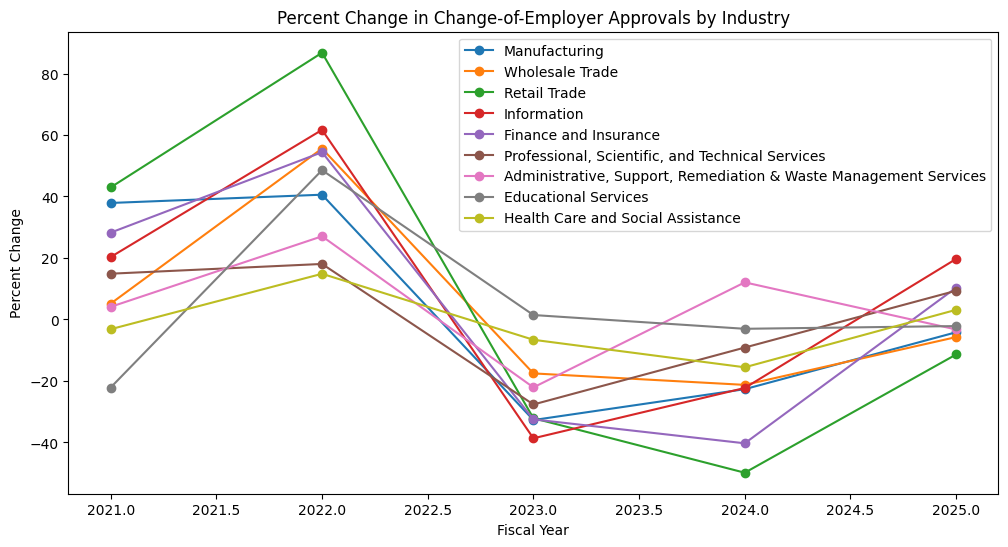

In [170]:
#Plotting each pct_change on a graph all together
industries = filtered_data["Industry (NAICS) Code"].unique()
plt.figure(figsize=(12, 6))

for industry in industries:
    industry_data = filtered_data[filtered_data["Industry (NAICS) Code"] == industry]
    plt.plot(industry_data["Fiscal Year"], industry_data["Percent Change"], marker='o', label=industry)

#Graph Details
plt.title("Percent Change in Change-of-Employer Approvals by Industry")
plt.xlabel("Fiscal Year")
plt.ylabel("Percent Change")
plt.legend()
plt.show()

###Interpreting Results

While this graph contains multiple overlapping lines, it effectively illustrates three key trends: H-1B transfer approvals increased across most industries from 2021 to 2022; all industries experienced a sharp decline from 2022 to 2023; and from 2023 to 2025, industries began diverging, with some recovering while others continued to decline.


The following graph highlights 'Professional, Scientific, and Technical Services' for closer analysis.

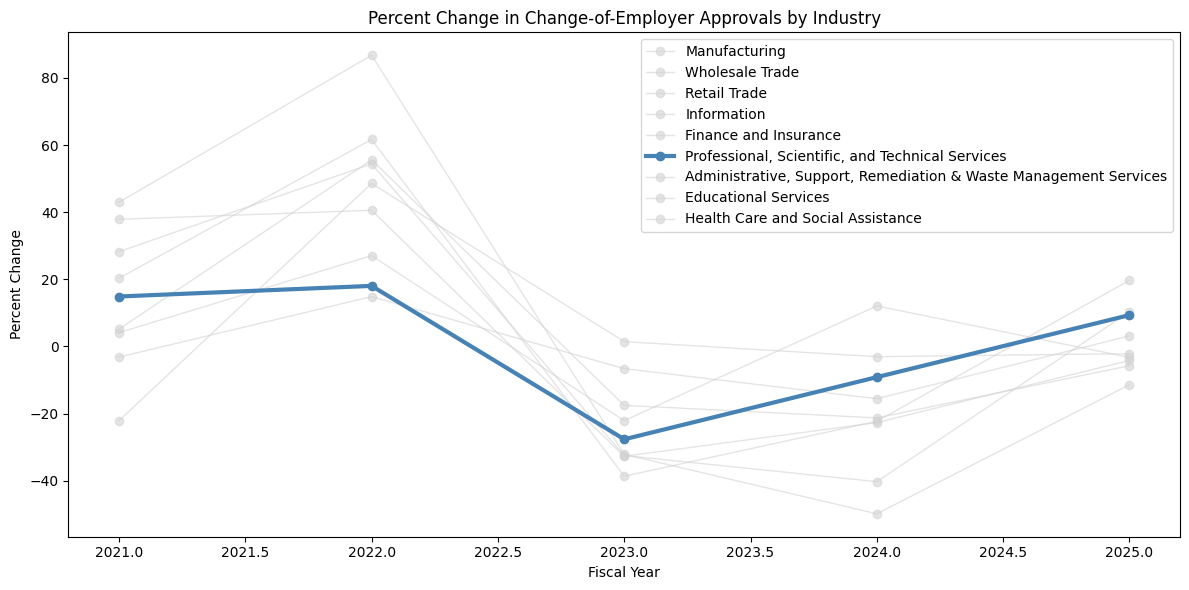

In [171]:
#Highlighting PST Line

fig, ax = plt.subplots(figsize=(12, 6))

for industry in industries:
    industry_data = filtered_data[filtered_data["Industry (NAICS) Code"] == industry]
    if industry == 'Professional, Scientific, and Technical Services':
        ax.plot(industry_data["Fiscal Year"], industry_data["Percent Change"],
                marker='o', linewidth=3, color='steelblue', label=industry, zorder=5)
    else:
        ax.plot(industry_data["Fiscal Year"], industry_data["Percent Change"],
                marker='o', linewidth=1, color='lightgray', alpha=0.6, label=industry)


ax.set_title("Percent Change in Change-of-Employer Approvals by Industry")
ax.set_xlabel("Fiscal Year")
ax.set_ylabel("Percent Change")
ax.legend()
plt.tight_layout()
plt.show()


###Further Interpretation:



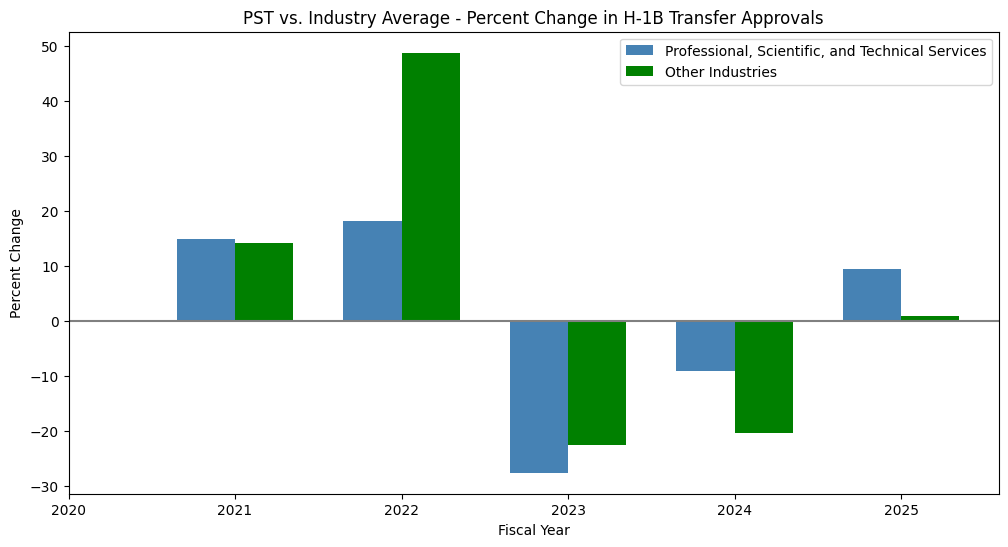

In [187]:
# Calculate average pct change of all OTHER industries per year

other_industry = filtered_data[filtered_data['Industry (NAICS) Code'] != 'Professional, Scientific, and Technical Services']
other_industry = other_industry.groupby('Fiscal Year')['Percent Change'].mean().reset_index()

pst_data = filtered_data[filtered_data['Industry (NAICS) Code'] == 'Professional, Scientific, and Technical Services']

#Graph
x = np.arange(len(pst_data['Fiscal Year']))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, pst_data['Percent Change'], width, label='Professional, Scientific, and Technical Services', color='steelblue')
ax.bar(x + width/2, other_industry['Percent Change'], width, label='Other Industries', color='green')

ax.set_xticks(x)
ax.set_xticklabels(pst_data['Fiscal Year'])
ax.set_title("PST vs. Industry Average - Percent Change in H-1B Transfer Approvals")
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Percent Change')
ax.axhline(y=0, color='grey', linestyle='-')
ax.legend()
plt.show()

Directly comparing PST transfer approval percent change against the average of all other industries reveals that non-PST industries broadly follow a similar trajectory to the IT-adjacent sector, but not to the letter. In 2022, other industries saw approximmately a 50% increase in transfer approval from 2021, which did not seem to materialize to the same degree in PST. Both groups declined in 2023, but PST experienced a steeper drop. By 2024, the trend reversed. Other industries declined further while PST began recovering. 2025 showed modest increases for both, but other industries barely returned to positive territory.

The 2023-2024 decline across both groups coincides with the widespread tech layoff wave, which saw major employers reduce headcount significantly. While this directly explains reduced mobility in PST, as workers are less likely to transfer during periods of active layoffs, it is unclear why industries outside of the technology sector followed the same pattern.

It is worth noting that the post-COVID recovery period appears reflected in the data, as the 2021-2022 increase in transfer approvals across all industries aligns with the broader market rebound following pandemic disruptions.

However, given that this analysis covers a short time frame and an economic turbulent widndow (2021-2025), these trends should be interpreted with caution. These short-term anommalies may not reflect long-run mobility patterns.

#Table 2: U.S Federal Reserve MacroEconomic Indicators

##Data Assembly

To compare the H-1B transfer rates, we will be using this dataset which compiles frequest reports of U.S. macroeconomic indicators, compiled primarily from the Federal Reserve Bank of St. Louis (FRED). Like the USCIS dataset, this dataset spans from a long period of time. Unlike the other dataset, however, we will need to refine it with code post-reading the CSV file.


    https://www.kaggle.com/datasets/halilaka/us-federal-reserve-daily-macroeconomic-indicators?resource=download

##Importing the Kaggle Dataset



In [173]:
#Importing fedreserve.csv

df_economy = pd.read_csv('/content/drive/MyDrive/notebooks/fedreserve.csv')
df_economy.head()

,date,cpi,fed_funds_rate,unemployment_rate,consumer_sentiment,treasury_3m,treasury_1y,treasury_10y,sofr_rate,money_supply_m2,real_gdp,industrial_production,housing_starts,retail_sales,mortgage_30y
0,1990-01-01,127.5,8.23,5.4,93.0,NaN,NaN,NaN,NaN,3166.8,10047.386,61.729,1551.0,NaN,NaN
1,1990-01-02,127.5,8.23,5.4,93.0,7.83,7.81,7.94,NaN,3166.8,10047.386,61.729,1551.0,NaN,NaN
2,1990-01-03,127.5,8.23,5.4,93.0,7.89,7.85,7.99,NaN,3166.8,10047.386,61.729,1551.0,NaN,NaN
3,1990-01-04,127.5,8.23,5.4,93.0,7.84,7.82,7.98,NaN,3166.8,10047.386,61.729,1551.0,NaN,NaN
4,1990-01-05,127.5,8.23,5.4,93.0,7.79,7.79,7.99,NaN,3166.8,10047.386,61.729,1551.0,NaN,9.83



##Key Variables:

Since this project aims to assess whether H-1B transfer petition rates reflect broader labor market conditions, the following economic indicators were selected:


*unemployment_rate:* The official unemployment rate as reported by the Federal Reserve Economic Data (FRED), representing the percentage of the labor force that is unemployed and actively seeking work.


*consumer_sentiment:* A composite economic indicator measuring consumer confidence in current and future economic conditions. Higher values indicate greater consumer confidence, which is generally associated with economic expansion and spending.


*date:* The date on which each observation was recorded.

###Refining the Dataset:

This dataset spans nearly 30 years of monthly observations. To align with the H-1B dataset, which is reported annually by fiscal year, the date column will be converted from mm/dd/yyyy format to year only.

In [174]:
#How is "date" stored?
df_economy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13164 entries, 0 to 13163
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   13164 non-null  object 
 1   cpi                    13164 non-null  float64
 2   fed_funds_rate         13164 non-null  float64
 3   unemployment_rate      13164 non-null  float64
 4   consumer_sentiment     13164 non-null  float64
 5   treasury_3m            13163 non-null  float64
 6   treasury_1y            13163 non-null  float64
 7   treasury_10y           13163 non-null  float64
 8   sofr_rate              2845 non-null   float64
 9   money_supply_m2        13164 non-null  float64
 10  real_gdp               13164 non-null  float64
 11  industrial_production  13164 non-null  float64
 12  housing_starts         13164 non-null  float64
 13  retail_sales           12434 non-null  float64
 14  mortgage_30y           13160 non-null  float64
dtypes:

In addition, as this dataset contains multiple observations per year, values were aggregated by annual mean for comparability with the H-1B fiscal year data.

This data will be converted to percent change to keep in line with H-1B transfer approvals being represented the same way.

In [175]:
#Converting object 'date' to int year.
df_economy['date'] = pd.to_datetime(df_economy['date']).dt.year

#Constraining dataset so that it is only 2020-2025
df_economy = df_economy[(df_economy['date'] > 2019) & (df_economy['date'] < 2026)]

#Grouping By Year and obtaining mean at the same time, as there are numerous values per one year.
df_economy_yearly = df_economy.groupby('date')[['unemployment_rate', 'consumer_sentiment']].mean().reset_index()

In [176]:
#Percent change for unemployment rate & consumer sentiment.

df_economy_yearly['unemployment_pct_change'] = df_economy_yearly['unemployment_rate'].pct_change() * 100
df_economy_yearly['consumer_sentiment_pct_change'] = df_economy_yearly['consumer_sentiment'].pct_change() * 100


##Visualizations

###Unemployment Rate v. Consumer Sentiment

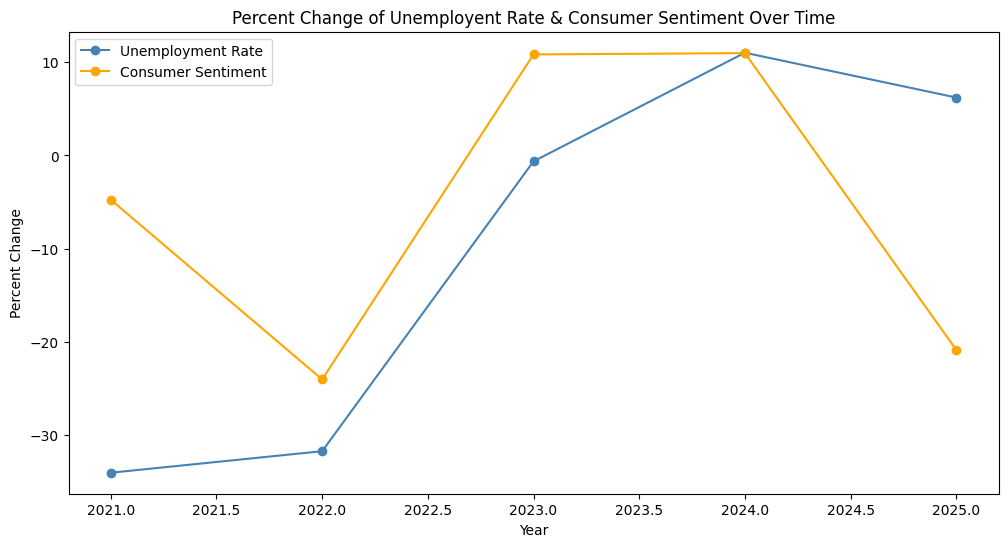

In [177]:
#plotting unemployment pct_change & consumemr_sentiment pct_change
plt.figure(figsize=(12, 6))
plt.plot(df_economy_yearly['date'], df_economy_yearly['unemployment_pct_change'], marker='o', color='steelblue')
plt.plot(df_economy_yearly['date'], df_economy_yearly['consumer_sentiment_pct_change'], marker ='o',  color='orange')
plt.title("Percent Change of Unemployent Rate & Consumer Sentiment Over Time")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.legend(['Unemployment Rate', 'Consumer Sentiment'])
plt.show()

####Interpretation:

From 2021 to 2022, the unemployment percent change stands deeply in the negative. This means that the labor market was relatively strong. Consumer sentiment, however, dropped from the positives down to the negatives. This suggest consumer's confidence dropped by factors other than employment.

From 2022 to 2023, unemployment percent change rose dramatically, from around negative 30% toward 0%. Unemployment rates were still on the decline, but decelerating. Consumer sentiment recovered sharply during this same period.

From 2023 to 2024, unemployment percent change crossed into positive territory, meaning the unemployment rate actually increased. This now indicates a weakening labor market. Consumer sentiment remained relatively stable during this period, suggesting consumers were not significantly affected by this rising unemployment.

Although unemployment rates were slowly increasing from 2024 to 2025, consumer confidence on the economy fell dramatically. This is an unexpected decline given the slight increase in unemployment.

The divergence observed in this graph suggests that consumer sentiment was driven by factors beyond the employment rate. These factors could be inflation, interest rates, etc.

###Other Industries H-1B Transfers v. Unemployment Rate

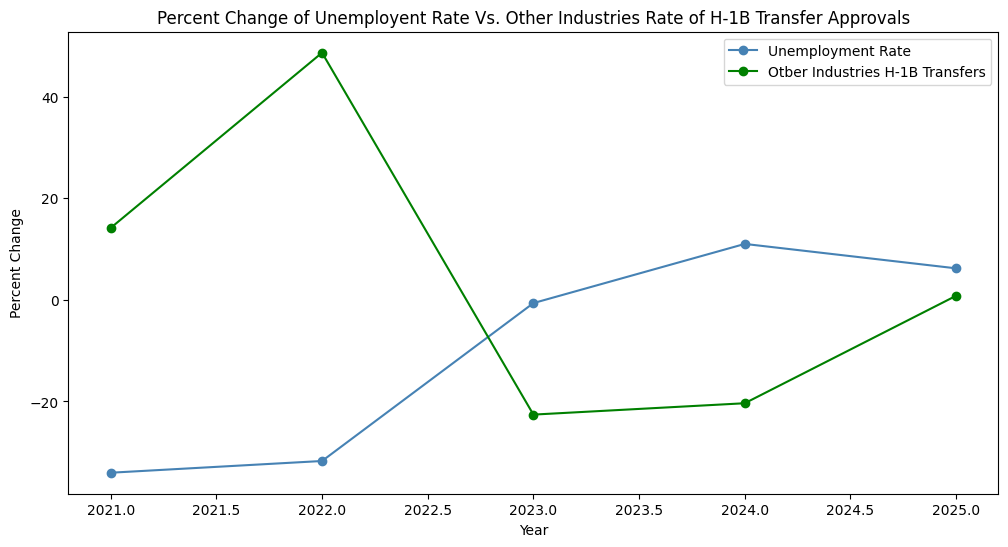

In [188]:

plt.figure(figsize=(12, 6))
plt.plot(df_economy_yearly['date'], df_economy_yearly['unemployment_pct_change'], marker='o', color='steelblue')
plt.plot(other_industry['Fiscal Year'], other_industry['Percent Change'], marker='o', color= "green")
plt.title("Percent Change of Unemployent Rate Vs. Other Industries Rate of H-1B Transfer Approvals")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.legend(['Unemployment Rate', 'Other Industries H-1B Transfers'])
plt.show()

####Interpretation:
As discussed in the earlier interpretation, from 2021 to 2023 the labor market is strong - as indicative of the falling unemployment rate. Although the rise of H-1B transfers coincide with a strong labor market in 2021-2022, transfers declined significantly heading into 2023.

The 2021 to 2022 data supports the thick labor market concept present in the literature, and since the H-1B transfers shown here are from non-IT industries, this finding suggests that non-IT H-1B workers also experience greater inter-firm mobility during periods of strong labor demand.

However, from 2022 to 2023, coinciding with widespread tech-sector layoffs, H-1B transfers decreased dramatically. After 2023, unemployment began rising, indicating a weakening economy. H-1B transfers reflect this weakening by continuing to decline, further reinforcing the theory that a tightening labor market weakened inter-firm mobility.

From 2024 to 2025, non-IT H-1B transfer approvals improved slightly as unemployment growth decelerated - supporting the theory again.

The data largely supports the thick labor market hypothesis, with H-1B transfer approvals declining during periods of rising unemployment and recovering as unemployment stabilizes. The primary exception is 2021-2022, where transfer approvals increased despite unemployment already trending downward. This likely reflects a post-COVID hiring boom rather than a contradiction of the theoretical framework.

###Other Industries H-1B Transfers v. Consumer Sentiment

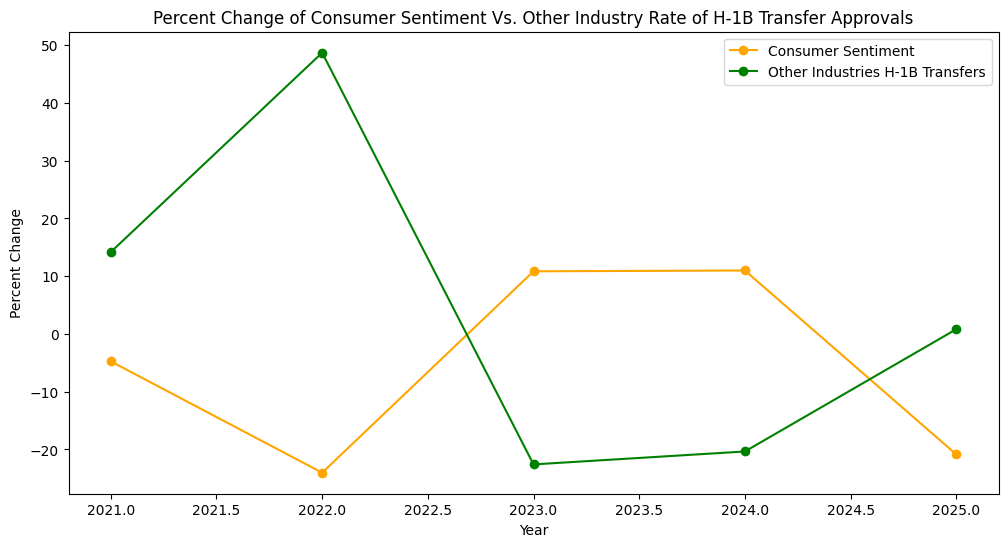

In [189]:
plt.figure(figsize=(12, 6))
plt.plot(df_economy_yearly['date'], df_economy_yearly['consumer_sentiment_pct_change'], marker ='o',  color='orange')
plt.plot(other_industry['Fiscal Year'], other_industry['Percent Change'], marker='o', color= "green")
plt.title("Percent Change of Consumer Sentiment Vs. Other Industry Rate of H-1B Transfer Approvals")
plt.xlabel("Year")
plt.ylabel("Percent Change")
plt.legend(['Consumer Sentiment', 'Other Industries H-1B Transfers'])
plt.show()

####Interpretation:


Shifting focus to consumer confidence, this section examines whether perceived economic strength coincides with H-1B transfer approval rates.

From 2021 to 2022, consumer sentiment was declining, indicating that confidence in the economy was weakening. Despite this, other industries' H-1B transfer approvals increased dramatically, which may reflect post-COVID labor market dynamics rather than consumer-driven hiring decisions.

From 2022 to 2023, consumer sentiment recovered, suggesting greater economic confidence. Yet H-1B transfers fell dramatically during the same period, coinciding with widespread tech-sector layoffs. Since layoffs were concentrated in the technology sector rather than the broader economy, it is not incongruous that consumer sentiment remained positive while transfer rates declined.

From 2023 to 2025, H-1B transfers continued declining, though at a decelerating pace approaching 2025. Consumer sentiment plateaued from 2023 to 2024 before falling sharply heading into 2025.

If current trends continue, H-1B transfers may begin recovering while consumer sentiment deteriorates further. This suggests that consumer sentiment may have limited predictive value for H-1B transfer rates, and that sector-specific labor market conditions may be a stronger determinant of inter-firm mobility than broader economic confidence indicators.